# Introduction to Binary Classification using `CatboostClassifierMother`

In this notebook, we tackle the binary classification problem of predicting the BBB (Blood-Brain Barrier) permeability from SMILES (Simplified Molecular Input Line Entry System) using the CatboostClassifierMother implementation. This tutorial not only demonstrates the application of CatBoost for binary classification but also explores advanced topics such as uncertainty estimation using virtual ensembles.

Unlike traditional ensembles that require training multiple models, virtual ensembles leverage the training process of a single model to simulate the behavior of an ensemble. This is achieved by introducing randomness into the training process, such as through different data permutations or variations in the training parameters.

In [1]:
# Import required libraries

from pathlib import Path
import requests
import logging
import pandas as pd
from rdkit import Chem
import numpy as np
from sklearn import pipeline as sklearn_pipeline
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import classification_report
from sklearn import pipeline as sklearn_pipeline
from sklearn.model_selection import GroupKFold, train_test_split, StratifiedKFold, GroupShuffleSplit
import warnings
from scipy.stats import pearsonr, spearmanr

import mother.ml as ml
from mother import cv as cv_module
from mother import feature_generation as fg
import mother.pipeline_utils as mother_takes_care
from mother.preprocessing import SmilesToMolTransformer, StandardizerTransformer
import mother.ml as ml_module

# Ensure plots are displayed inline
%matplotlib inline
logging.basicConfig(level=logging.INFO)
warnings.filterwarnings("ignore")

In [2]:
# helper functions
def check_and_drop_smiles_duplicates(data: pd.DataFrame) -> pd.DataFrame:
    initial_count = len(data)
    print(f"Initial SMILES count: {initial_count}")
    duplicate_count = data.duplicated(subset=["smiles"]).sum()
    print(f"Number of duplicate SMILES: {duplicate_count}")
    data = data.drop_duplicates(subset=["smiles"], keep="first")
    final_count = len(data)
    print(f"Final SMILES count after dropping duplicates: {final_count}")

    return data


def check_and_drop_inconsistent_smiles_labels(data: pd.DataFrame) -> pd.DataFrame:
    # Group by SMILES and check for differing labels
    inconsistent_smiles = data.groupby("smiles")["p_np"].nunique()
    differing_labels = inconsistent_smiles[inconsistent_smiles > 1]
    print(f"Number of SMILES with differing labels: {len(differing_labels)}")
    # Drop rows with inconsistent SMILES
    data = data[~data["smiles"].isin(differing_labels.index)]
    print(f"Final data count after dropping inconsistent SMILES: {len(data)}")

    return data


def validate_smiles(smiles: str) -> bool:
    """Check if a SMILES string is valid."""
    if isinstance(smiles, str):
        return Chem.MolFromSmiles(smiles) is not None
    return False


def download_bbbp_dataset():
    """Download BBBP dataset from GitHub repository"""

    # Create data directory if it doesn't exist
    data_dir = Path("../data")
    data_dir.mkdir(exist_ok=True)

    # File path for BBBP dataset
    bbbp_path = data_dir / "BBBP.csv"

    # Download if file doesn't exist
    if not bbbp_path.exists():
        print("🌐 Downloading BBBP dataset from GitHub repository...")
        try:
            url = "https://raw.githubusercontent.com/GLambard/Molecules_Dataset_Collection/refs/heads/master/latest/BBBP.csv"
            response = requests.get(url)
            response.raise_for_status()  # Raises an HTTPError for bad responses

            with open(bbbp_path, "wb") as f:
                f.write(response.content)

            print(f"✅ Dataset saved to {bbbp_path}")
        except Exception as e:
            print(f"❌ Download failed: {e}")
            return None
    else:
        print(f"✅ Dataset already exists at {bbbp_path}")

    return bbbp_path

### Import Data
Load the data from the input file and limit the data to 100 rows for testing purposes.
The data file contains a column with the molecular structure (__Molecule__) and a column with the target value (__p_np__).



In [3]:
input_file = download_bbbp_dataset()
data: pd.DataFrame = pd.read_csv(input_file, sep=",")


data = data[["name", "p_np", "smiles"]]  # type: ignore
data["smiles"] = data["smiles"].astype(str)
print(f"Number of NA values in 'p_np' column: {data['p_np'].isna().sum()}")
class_counts = data["p_np"].value_counts()
print(class_counts)
data.head()

✅ Dataset already exists at ../data/BBBP.csv
Number of NA values in 'p_np' column: 0
p_np
1    1567
0     483
Name: count, dtype: int64


,name,p_np,smiles
0,Propanolol,1,CC(C)NCC(O)COC1:C:C:C:C2:C:C:C:C:C:1:2.[Cl]
1,Terbutylchlorambucil,1,CC(C)(C)OC(=O)CCCC1:C:C:C(N(CCCl)CCCl):C:C:1
2,40730,1,CC1COC2:C(N3CCN(C)CC3):C(F):C:C3:C(=O):C(C(=O)...
3,24,1,CC(=O)NCCCOC1:C:C:C:C(CN2CCCCC2):C:1
4,cloxacillin,1,CC1:O:N:C(C2:C:C:C:C:C:2Cl):C:1C(=O)N[C@@H]1C(...


### Initial SMILES preprocessing

We apply previously defined helper functions to clean the dataset by removing duplicates and inconsistent SMILES entries. 

In [4]:
data = check_and_drop_smiles_duplicates(data)
data = check_and_drop_inconsistent_smiles_labels(data)
data["is_valid_smiles"] = data["smiles"].apply(validate_smiles)
print(f"------------------------Number of invalid SMILES: {(~data['is_valid_smiles']).sum()}")
# Filter out invalid SMILES
data = data[data["is_valid_smiles"]]
print(f"------------------------Lenght of cleaned data: {len(data)}")

Initial SMILES count: 2050
Number of duplicate SMILES: 74
Final SMILES count after dropping duplicates: 1976
Number of SMILES with differing labels: 0
Final data count after dropping inconsistent SMILES: 1976


[06:10:08] SMILES Parse Error: syntax error while parsing: nan
[06:10:08] SMILES Parse Error: check for mistakes around position 2:
[06:10:08] nan
[06:10:08] ~^
[06:10:08] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom w

------------------------Number of invalid SMILES: 1
------------------------Lenght of cleaned data: 1975


[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not removing hydrogen atom without neighbors
[06:10:08] WARNING: not r

### Preprocessing

Here, we take utilize a standard Mother preprocessing pipeling. It consists of two steps:
1. Standardize the molecular structure using the __StandardizerTransformer__.
2. Convert the standardized SMILES to a molecule object using the __SmilesToMolTransformer__.

Subsequently, we check for invalid molecules after preprocessing. 

In [5]:
preprocessor: sklearn_pipeline.Pipeline = sklearn_pipeline.Pipeline(
    [
        (
            "smiles_standardizer",
            StandardizerTransformer(flags=["STANDARDIZE", "NEUTRALIZE", "DESALT"]),
        ),
        ("smiles_to_mol", SmilesToMolTransformer()),
        # Add other column transformations here if needed
    ],
    memory=None,
).set_output(transform="pandas")

structure_data: pd.Series = data["smiles"]
print(f"------------------------Number of NA values in 'smiles' column: {structure_data.isna().sum()}")


# Preprocess the SMILES strings
mol_data: pd.DataFrame = preprocessor.fit_transform(structure_data)

# Check for invalid molecules after preprocessing
invalid_molecules = mol_data["Molecule"].isna().sum()
print(f"------------------------Number of NaN molecules after preprocessing: {invalid_molecules}")

# Drop rows with invalid molecules if necessary
if invalid_molecules > 0:
    print("Dropping rows with invalid molecules...")
    mol_data = mol_data.dropna(subset=["Molecule"])

print(f"------------------------Number of valid molecules: {len(mol_data)}")

mol_data.head()

INFO:mother.preprocessing.core:Standardizing SMILES with flags: ['STANDARDIZE', 'NEUTRALIZE', 'DESALT']
[06:10:10] Initializing Normalizer
[06:10:10] Initializing Normalizer
[06:10:10] Initializing MetalDisconnector
[06:10:10] Initializing Normalizer
ERROR:mother.preprocessing.core:Catched exception from RDKit during standardization of SMILES with INDEX: 11
ERROR:mother.preprocessing.core:Catched exception from RDKit during standardization of SMILES with INDEX: 22
ERROR:mother.preprocessing.core:Catched exception from RDKit during standardization of SMILES with INDEX: 36


------------------------Number of NA values in 'smiles' column: 0


ERROR:mother.preprocessing.core:Catched exception from RDKit during standardization of SMILES with INDEX: 53
ERROR:mother.preprocessing.core:Catched exception from RDKit during standardization of SMILES with INDEX: 56
[06:10:10] WARNING: not removing hydrogen atom without neighbors
[06:10:10] Running MetalDisconnector
[06:10:10] Running FragmentRemover
[06:10:10] Removed fragment: hydrogen
[06:10:10] Removed fragment: chlorine
[06:10:10] Running LargestFragmentChooser
[06:10:10] Running Uncharger
[06:10:10] Running Normalizer

ERROR:mother.preprocessing.core:Catched exception from RDKit during standardization of SMILES with INDEX: 60
ERROR:mother.preprocessing.core:Catched exception from RDKit during standardization of SMILES with INDEX: 62
ERROR:mother.preprocessing.core:Catched exception from RDKit during standardization of SMILES with INDEX: 78
ERROR:mother.preprocessing.core:Catched exception from RDKit during standardization of SMILES with INDEX: 84
ERROR:mother.preprocessing.core

------------------------Number of NaN molecules after preprocessing: 0
------------------------Number of valid molecules: 1975


,Molecule
0,<rdkit.Chem.rdchem.Mol object at 0x71db3b6d92a0>
1,<rdkit.Chem.rdchem.Mol object at 0x71db3b6d9380>
2,<rdkit.Chem.rdchem.Mol object at 0x71db3b6d93f0>
3,<rdkit.Chem.rdchem.Mol object at 0x71db3b6d9460>
4,<rdkit.Chem.rdchem.Mol object at 0x71db3b6d94d0>


### Feature Generation
By combining multiple feature generators, we can create a feature matrix that contains various types of features. By default, we are combining _MACCS_ fingerprints, _Morgan_ fingerprints, and _Chemical Descriptors_.

In [6]:
feature_generator = sklearn_pipeline.FeatureUnion(
    transformer_list=[
        ("maccs", fg.MaccsFingerprints()),
        ("morgan", fg.MorganFingerprints()),
        ("desc", fg.ChemicalDescriptors()),
    ],
).set_output(transform="pandas")


features: pd.DataFrame = feature_generator.fit_transform(mol_data["Molecule"])

features

INFO:mother.feature_generation.core:Calculating MACCS fingerprints
INFO:mother.feature_generation.core:Calculating MorganFP fingerprints using parameters: {'radius': 2, 'fpSize': 1024, 'includeChirality': False}
INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'


,maccs__maccs_0,maccs__maccs_1,maccs__maccs_2,maccs__maccs_3,maccs__maccs_4,maccs__maccs_5,maccs__maccs_6,maccs__maccs_7,maccs__maccs_8,maccs__maccs_9,...,desc__fr_sulfide,desc__fr_sulfonamd,desc__fr_sulfone,desc__fr_term_acetylene,desc__fr_tetrazole,desc__fr_thiazole,desc__fr_thiocyan,desc__fr_thiophene,desc__fr_unbrch_alkane,desc__fr_urea
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1971,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1972,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1973,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Grouping for Cross-Validation
To ensure that the training and validation sets do not contain similar molecules, we group the molecules based on their similarity. We use the Tanimoto similarity to group molecules with a similarity threshold of 0.4. 

In [7]:
# cv grouping
groups_engine = cv_module.TanimotoGroupingFromMols(similarity_threshold=0.4)

groups: pd.DataFrame = groups_engine.set_output(transform="pandas").fit_transform(mol_data["Molecule"])

cv = GroupKFold(n_splits=5)

print(f"{groups['tanimoto-group'].nunique()} groups found")

INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'
INFO:mother.cv.cv_methods:Applying clustering with Tanimoto similarity: 0.4
INFO:mother.cv.cv_methods:Found: 889 clusters


889 groups found


We create training and testing subsets, while ensuring that there is no overlap between the groups in the training and testing sets. 

In [8]:
groups = groups["tanimoto-group"].astype(int)

gss = GroupShuffleSplit(test_size=0.3, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(features, data["p_np"], groups=groups))
print(f"train_index [:5]: {train_idx[:5]}")
print(f"test_idx [:5]: {test_idx[:5]}")

# Subset the data
X_train, X_test = features.iloc[train_idx], features.iloc[test_idx]
y_train, y_test = data["p_np"].iloc[train_idx], data["p_np"].iloc[test_idx]

# Ensure no group overlap
train_groups = groups.iloc[train_idx].unique()
test_groups = groups.iloc[test_idx].unique()

assert len(set(train_groups) & set(test_groups)) == 0, "Group overlap detected!"

train_index [:5]: [0 1 3 4 6]
test_idx [:5]: [ 2  5  7 10 23]


Finally, we define the settings for the model and the pipeline including: feature selection flags, cross-validation configurations.

In [9]:
model_settings = {
    "feature_selection_flags": ["DROP_CORRELATED", "DROP_CONSTANT", "DROP_DUPLICATES", "DROP_UNIMPORTANT"],
    "feature_selection_threshold": 0,
    "correlation_threshold": 0.9,
    "algorithm": "catboost",
    "feature_selection_type": "catboost",
    "cv": cv,
    "cv_groups": groups,
    "cv_splits": 5,
}
pipeline_settings = {
    "remainder": "passthrough",
    "verbose_feature_names_out": False,
}
model_settings["model_type"] = "regression"
model_settings["target_type"] = "single_target"

model = ml.PipelineWithHyperparameterRooting(
    [
        (
            "feature_selector",
            mother_takes_care.get_feature_selection_pipeline(
                settings=model_settings, pipeline_settings=pipeline_settings
            ).set_output(transform="pandas"),
        ),
        (
            "ml_model",
            ml_module.CatboostClassifierMother(
                target_type="single_target", tune_boosting_type=False, logging_level="Silent"
            ),
        ),
    ]
)

INFO:mother.pipeline_utils:Creating feature selection pipeline for numeric columns.
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.ml:Loaded 9 model classes: CatboostClassifierMother, CatboostGaussianProcessRegressorMother, CatboostRankerMother, CatboostRegressorMother, LassoClassifierBinaryMother, LassoClassifierMulticlassMother, LassoRegressorMother, RandomForestClassifierMother, RandomForestRegressorMother
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.pipeline_utils:Setting up catboost importance feature selection
INFO:mother.ml.utils:Using 'Logloss' as loss function.
INFO:mother.ml.utils:Using 'Logloss' as loss function.


### Model Training and Validation using Stratified K-Fold Cross-Validation

In [10]:
X = features
y = data["p_np"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, val_index in skf.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    model.fit(X_train_fold, y_train_fold)

    # Validate the model on the cv fold
    y_pred = model.predict(X_val_fold)

    # Print classification report for each fold
    print(classification_report(y_val_fold, y_pred))

# Final evaluation on the test set
model.fit(X_train, y_train)
y_test_pred = model.predict_proba(X_test)

INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator


              precision    recall  f1-score   support

           0       0.81      0.79      0.80        75
           1       0.93      0.94      0.94       241

    accuracy                           0.91       316
   macro avg       0.87      0.86      0.87       316
weighted avg       0.90      0.91      0.90       316



INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator


              precision    recall  f1-score   support

           0       0.83      0.84      0.84        76
           1       0.95      0.95      0.95       240

    accuracy                           0.92       316
   macro avg       0.89      0.89      0.89       316
weighted avg       0.92      0.92      0.92       316



INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator


...

INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator


              precision    recall  f1-score   support

           0       0.87      0.80      0.84        76
           1       0.94      0.96      0.95       240

    accuracy                           0.92       316
   macro avg       0.91      0.88      0.89       316
weighted avg       0.92      0.92      0.92       316



INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator


              precision    recall  f1-score   support

           0       0.78      0.64      0.71        76
           1       0.89      0.94      0.92       240

    accuracy                           0.87       316
   macro avg       0.84      0.79      0.81       316
weighted avg       0.87      0.87      0.87       316



INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator


### Evaluating the discriminative power of the model between the two classes.
AUC-ROC (Area Under the Receiver Operating Characteristic Curve) evaluates whether the model assigns a higher probability to a randomly chosen positive example compared to a randomly chosen negative example. In other words, this score measures how well the model can `order or rank` predictions based on their likelihood of belonging to the target/positive class. This is a ranking problem because it focuses on the relative ordering of predictions, not their absolute values.


- A score of 0.96 means that there is a 96% chance that the model will rank a randomly chosen positive instance higher than a randomly chosen negative instance. it indicates that the model has excellent discriminative power.

In the context of binary classification:

- Positive Examples: These are the instances that belong to the class of interest (the target class). For example, in a medical diagnosis task, positive examples could represent patients with a specific disease.

- Negative Examples: These are the instances that do not belong to the class of interest. In the same medical diagnosis task, negative examples would represent patients without the disease.

`N.B.` AUC-ROC does not depend on a specific decision threshold (e.g., 0.5 for classification). Instead, it evaluates the model's ability to rank predictions correctly across all possible thresholds.

AUC-ROC: 0.93


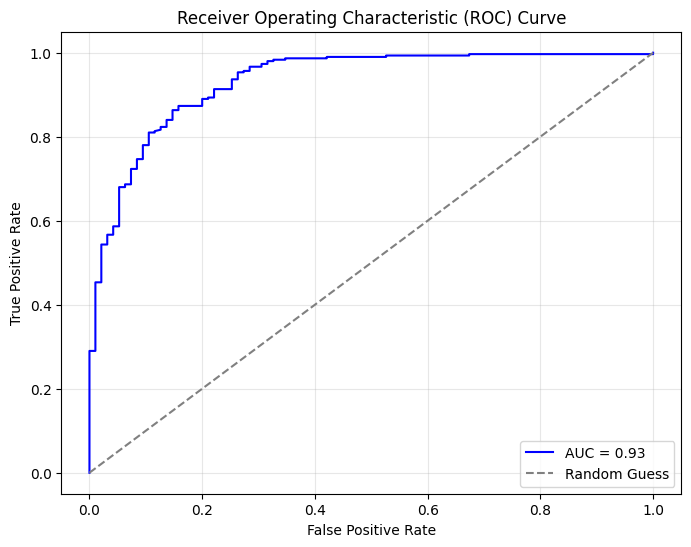

In [11]:
# evaluate the discriminative power of the model between the two classes.
from sklearn.metrics import roc_auc_score, roc_curve

# Calculate AUC-ROC: Measures the model's ability to rank predictions.
auc = roc_auc_score(y_test, y_test_pred[:, 1])
print(f"AUC-ROC: {auc:.2f}")

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred[:, 1])

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [12]:
from sklearn.metrics import log_loss

logloss = log_loss(y_test, y_test_pred[:, 1])
print(f"Log Loss: {logloss:.3f}")

Log Loss: 0.272


### Evaluating the uncertainty method
The `calibration curve` evaluates how well the predicted probabilities align with the true probabilities. It provides insights into the model's calibration, which measures whether the predicted confidence levels reflect the actual likelihood of correctness.

How it works:

Predicted probabilities are grouped into bins (e.g., 0.0–0.1, 0.1–0.2, etc.).
For each bin, the average predicted probability (prob_pred) is compared to the actual fraction of positive samples (prob_true).

- Example:
If a bin contains predicted probabilities [0.15, 0.18, 0.12] and the  corresponding true labels are [1, 0, 1]:

- prob_pred for the bin = Average of [0.15, 0.18, 0.12] = 0.15.
prob_true for the bin = Average of [1, 0, 1] = 0.67. (sum/total=2/3)

This process is repeated for all bins, resulting in arrays of prob_true and prob_pred.

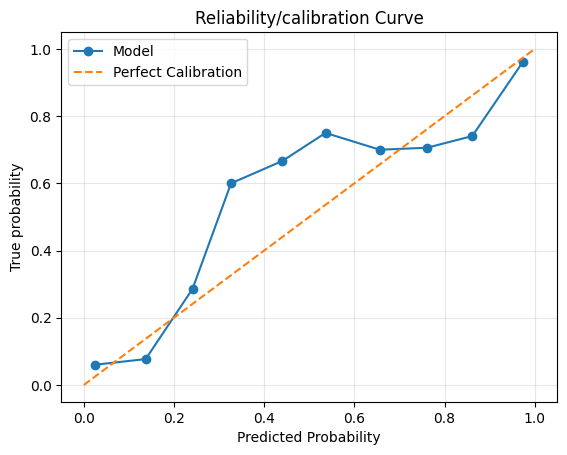

In [13]:
# Generate reliability diagram
prob_true, prob_pred = calibration_curve(y_test, y_test_pred[:, 1], n_bins=10)

# Plot reliability diagram
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.xlabel("Predicted Probability")
plt.ylabel("True probability")
plt.title("Reliability/calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

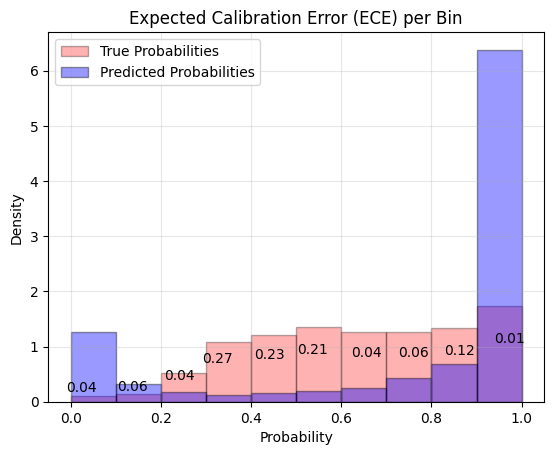

In [14]:
# Generate calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_test_pred[:, 1], n_bins=10)

# Define bins for both histograms
bins = np.linspace(0, 1, 11)  # Creates evenly spaced bins between 0 and 1 (total 11)

# Calculate ECE per bin
ece_per_bin = np.abs(prob_true - prob_pred)

# Plot histogram of true probabilities (scaled to match predicted probabilities)
plt.hist(
    prob_pred,
    bins=bins,
    weights=prob_true,
    alpha=0.3,
    label="True Probabilities",
    color="red",
    edgecolor="black",
    density=True,
)

# Plot histogram of predicted probabilities
plt.hist(
    y_test_pred[:, 1],
    bins=bins,
    alpha=0.4,
    label="Predicted Probabilities",
    color="blue",
    edgecolor="black",
    density=True,
)

# Annotate ECE per bin
for i in range(len(prob_pred)):
    plt.text(
        prob_pred[i], prob_true[i] + 0.06, f"{ece_per_bin[i]:.2f}", fontsize=10, color="black", ha="center", va="bottom"
    )

# Add labels and legend
plt.xlabel("Probability")
plt.ylabel("Density")
plt.title("Expected Calibration Error (ECE) per Bin")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [16]:
all_uncertainty = model.predict_uncertainty(
    X=X_test, ml_model__n_ensembles=10, ml_model__n_threads=1, ml_model__uncertainty_for_opt=False
)

all_uncertainty

INFO:mother.ml.utils:Using catboost's builtin uncertainty prediction


,mean_predictions,knowledge_uncertainty,data_uncertainty,total_uncertainty
397,None,0.000420,0.037963,0.038383
1648,None,0.000584,0.075700,0.076284
1090,None,0.000424,0.041800,0.042224
772,None,0.000352,0.044660,0.045012
842,None,0.000164,0.081945,0.082109
...,...,...,...,...
418,None,0.000055,0.317925,0.317980
245,None,0.002647,0.175006,0.177653
1520,None,0.000106,0.048102,0.048208
887,None,0.000336,0.386719,0.387055


In [17]:
model_uncertainty = model.predict_uncertainty(
    X=X_test, ml_model__n_ensembles=10, ml_model__n_threads=1, ml_model__uncertainty_for_opt=True
)
model_uncertainty.head()

INFO:mother.ml.utils:Using catboost's builtin uncertainty prediction


,knowledge_uncertainty
397,0.000420
1648,0.000584
1090,0.000424
772,0.000352
842,0.000164


Spearman correlation: predicted prob and model uncertainty: -0.05 (p-value: 3.54e-01)
Pearson correlation: predicted prob and model uncertainty: 0.08 (p-value: 9.26e-02)


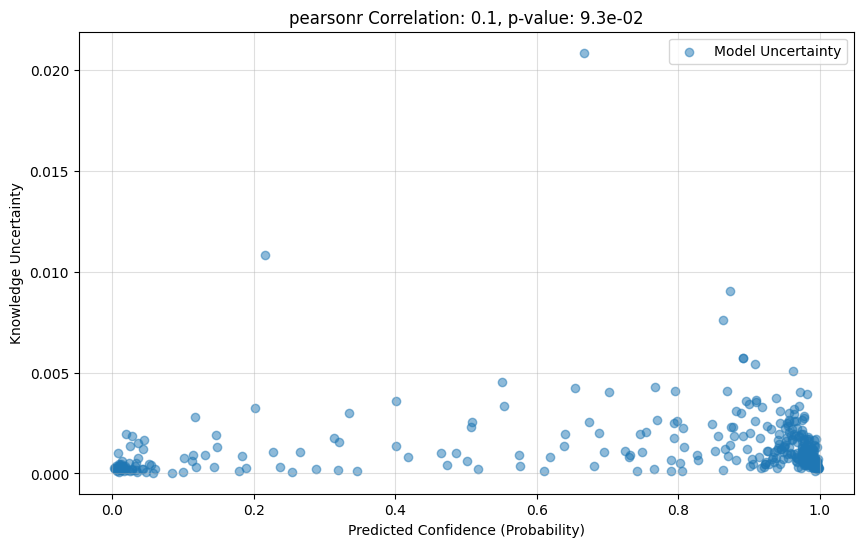

In [18]:
# add correlation between model uncertainty and predicted probability
# Calculate correlation and its p value
corr, p_value = spearmanr(y_test_pred[:, 1], all_uncertainty["knowledge_uncertainty"])
print(f"Spearman correlation: predicted prob and model uncertainty: {corr:.2f} (p-value: {p_value:.2e})")
# pearsor correlation
corr_pear, p_value_pear = pearsonr(y_test_pred[:, 1], all_uncertainty["knowledge_uncertainty"])
print(f"Pearson correlation: predicted prob and model uncertainty: {corr_pear:.2f} (p-value: {p_value_pear:.2e})")

plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred[:, 1], all_uncertainty["knowledge_uncertainty"], alpha=0.5, label="Model Uncertainty")

plt.xlabel("Predicted Confidence (Probability)")
plt.ylabel("Knowledge Uncertainty")  #
plt.legend()
plt.title(f"pearsonr Correlation: {corr_pear:.1f}, p-value: {p_value_pear:.1e}")
plt.grid(alpha=0.4)
plt.show()

Spearman correlation: predicted prob and total uncertainty: -0.64 (p-value: 1.26e-47)
Pearson correlation: predicted prob and total uncertainty: -0.23 (p-value: 2.48e-06)


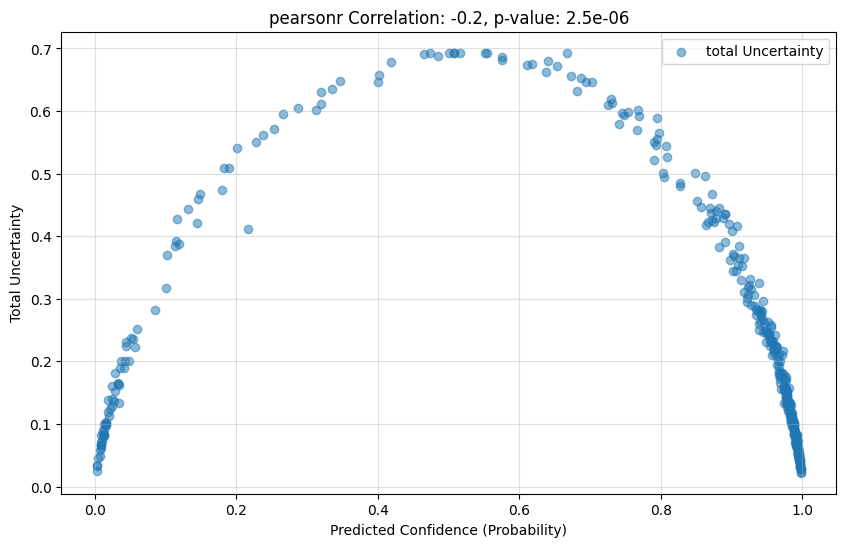

In [19]:
corr, p_value = spearmanr(y_test_pred[:, 1], all_uncertainty["total_uncertainty"])
print(f"Spearman correlation: predicted prob and total uncertainty: {corr:.2f} (p-value: {p_value:.2e})")
# pearsor correlation
corr_pear, p_value_pear = pearsonr(y_test_pred[:, 1], all_uncertainty["total_uncertainty"])
print(f"Pearson correlation: predicted prob and total uncertainty: {corr_pear:.2f} (p-value: {p_value_pear:.2e})")

plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred[:, 1], all_uncertainty["total_uncertainty"], alpha=0.5, label="total Uncertainty")

plt.xlabel("Predicted Confidence (Probability)")
plt.ylabel("Total Uncertainty")  #
plt.legend()
plt.title(f"pearsonr Correlation: {corr_pear:.1f}, p-value: {p_value_pear:.1e}")
plt.grid(alpha=0.4)
plt.show()

Spearman correlation: model uncertainty and ECE: 0.13 (p-value: 7.26e-01)
Pearson correlation: model uncertainty and ECE: -0.08 (p-value: 8.27e-01)


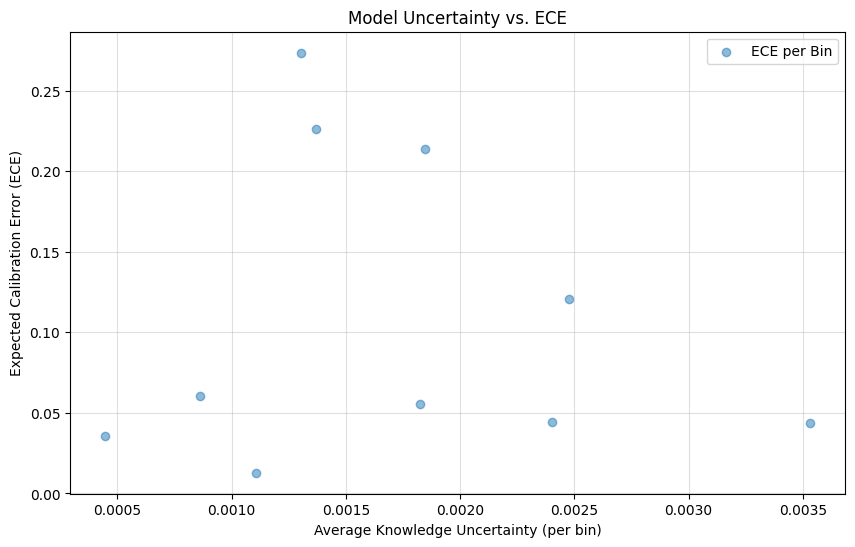

In [20]:
# Generate calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_test_pred[:, 1], n_bins=10)

# Calculate ECE per bin
ece_per_bin = np.abs(prob_true - prob_pred)

# Bin model uncertainty into the same bins as ECE
bins = np.linspace(0, 1, 11)  # Define bin edges
uncertainty_bins = np.digitize(y_test_pred[:, 1], bins) - 1  # Assign each sample to a bin (0-indexed)
avg_uncertainty_per_bin = [
    all_uncertainty["knowledge_uncertainty"][uncertainty_bins == i].mean() for i in range(len(prob_true))
]
# correlation between model uncertainty and ECE
corr, p_value = spearmanr(avg_uncertainty_per_bin, ece_per_bin)
print(f"Spearman correlation: model uncertainty and ECE: {corr:.2f} (p-value: {p_value:.2e})")
# pearsor correlation
corr_pear, p_value_pear = pearsonr(avg_uncertainty_per_bin, ece_per_bin)
print(f"Pearson correlation: model uncertainty and ECE: {corr_pear:.2f} (p-value: {p_value_pear:.2e})")
# Scatter plot: Model uncertainty vs. ECE
plt.figure(figsize=(10, 6))
plt.scatter(avg_uncertainty_per_bin, ece_per_bin, alpha=0.5, label="ECE per Bin")

# Add labels and title
plt.xlabel("Average Knowledge Uncertainty (per bin)")
plt.ylabel("Expected Calibration Error (ECE)")
plt.title("Model Uncertainty vs. ECE")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

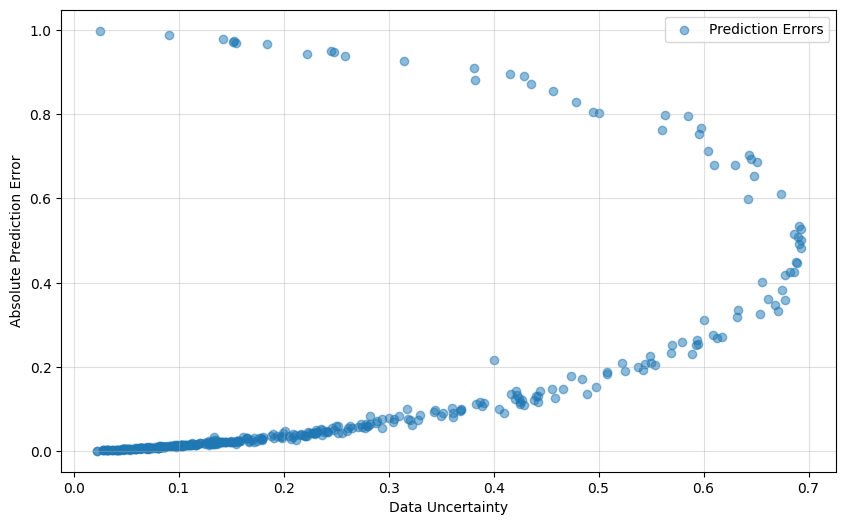

In [21]:
# Calculate prediction errors
prediction_errors = y_test_pred[:, 1] - y_test  # Assuming y_test_pred[:, 1] is the probability for the positive class

# Take the absolute value of prediction errors
abs_prediction_errors = np.abs(prediction_errors)

# Scatter plot: Model uncertainty vs. Absolute prediction errors
plt.figure(figsize=(10, 6))
plt.scatter(all_uncertainty["data_uncertainty"], abs_prediction_errors, alpha=0.5, label="Prediction Errors")

# Add labels and title
plt.xlabel("Data Uncertainty")
plt.ylabel("Absolute Prediction Error")
plt.title("")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

-  This plot below shows how the model's accuracy changes as more samples are included, sorted by their uncertainty. It helps evaluate the model's performance under different levels of uncertainty and assess its reliability.

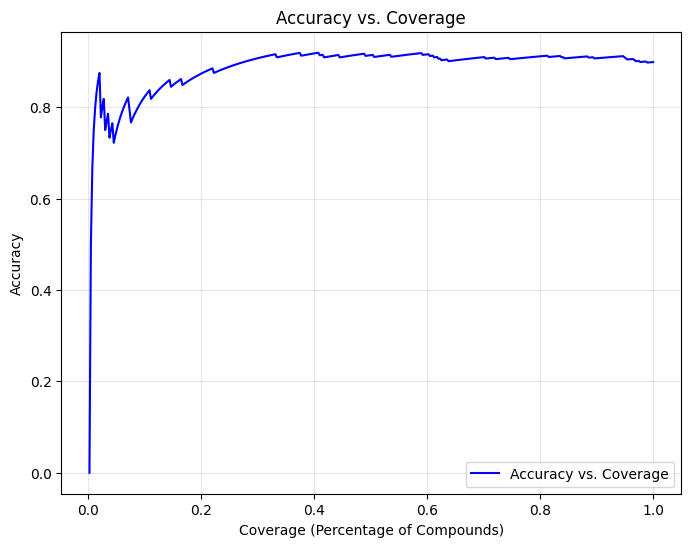

In [22]:
# Sort predictions by uncertainty (ascending)
sorted_indices = np.argsort(all_uncertainty["knowledge_uncertainty"])
sorted_uncertainty = all_uncertainty["knowledge_uncertainty"].iloc[sorted_indices]  # ascending order.
sorted_y_test = y_test.iloc[sorted_indices]
sorted_y_pred = y_test_pred[sorted_indices]

# Calculate cumulative coverage and accuracy
coverage = np.arange(1, len(sorted_y_test) + 1) / len(sorted_y_test)
accuracy = np.cumsum(sorted_y_test == sorted_y_pred.argmax(axis=1)) / np.arange(1, len(sorted_y_test) + 1)

# Plot accuracy vs. coverage
plt.figure(figsize=(8, 6))
plt.plot(coverage, accuracy, label="Accuracy vs. Coverage", color="blue")
plt.xlabel("Coverage (Percentage of Compounds)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Coverage")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

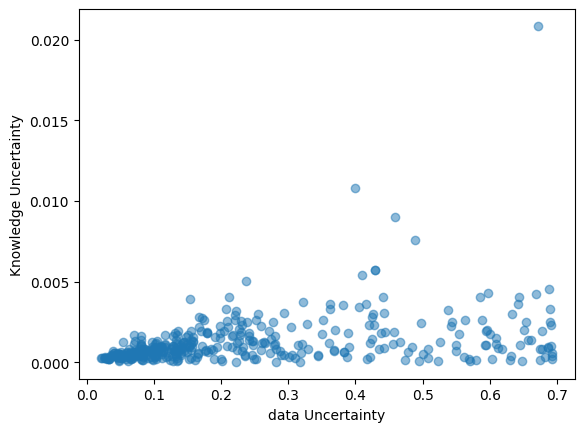

In [23]:
# Example: Scatter plot of aleatoric vs. epistemic uncertainty
plt.scatter(all_uncertainty["data_uncertainty"], all_uncertainty["knowledge_uncertainty"], alpha=0.5)
plt.xlabel("data Uncertainty")
plt.ylabel("Knowledge Uncertainty")
plt.title("")
plt.show()